# Customer Churn Prediction

End-to-end pipeline: **EDA → preprocessing → Logistic Regression → evaluation**.

**Primary metric:** ROC AUC  
**Business goal:** Correctly identify customers who will churn (high recall on the positive class)

## 1. Setup & Imports

In [24]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Data

In [25]:
df = pd.read_csv('customer_churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis (EDA)

In [26]:
print('Column types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Column types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBillin

In [27]:
# TotalCharges stored as object — some rows are blank strings
blank_total = (df['TotalCharges'].astype(str).str.strip() == '').sum()
print(f'Blank TotalCharges values: {blank_total}')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'TotalCharges nulls after conversion: {df["TotalCharges"].isnull().sum()}')

Blank TotalCharges values: 11
TotalCharges nulls after conversion: 11


In [28]:
print('Summary statistics (numeric):')
df.describe()

Summary statistics (numeric):


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


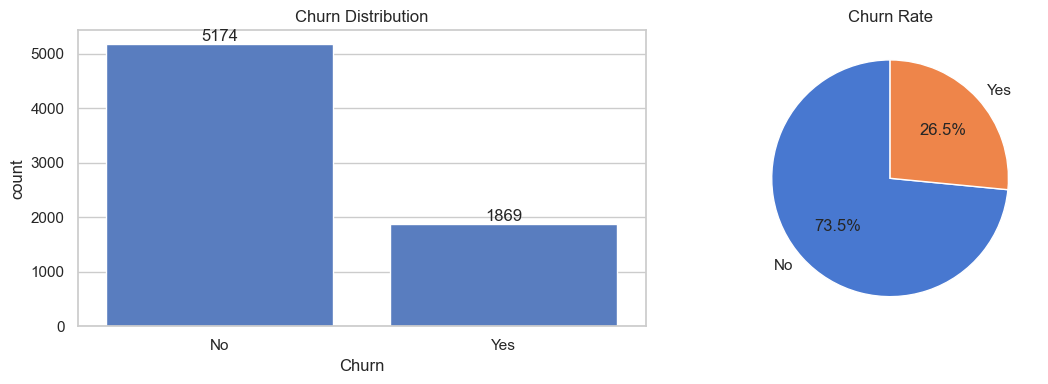

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [29]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='Churn', ax=axes[0])
axes[0].set_title('Churn Distribution')
axes[0].bar_label(axes[0].containers[0])

axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn Rate')
plt.tight_layout()
plt.show()

print(churn_pct.round(2))

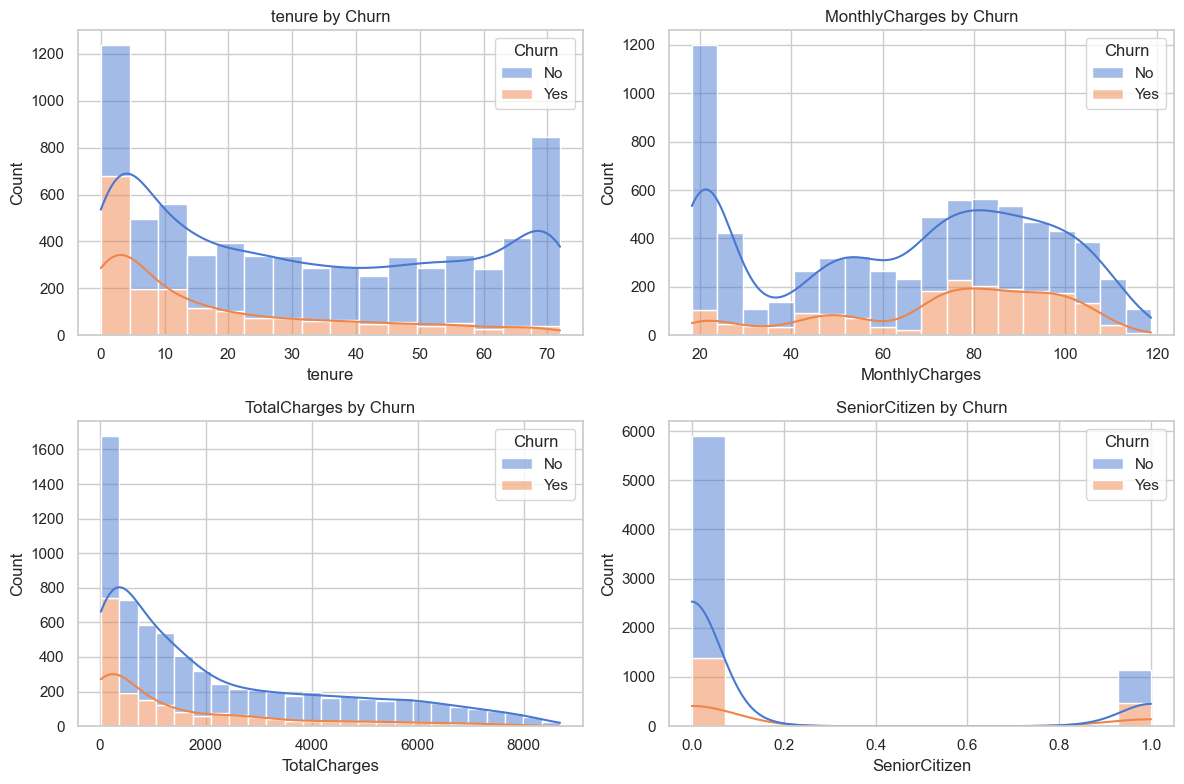

In [30]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax, multiple='stack')
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

In [31]:
categorical_cols = [c for c in df.columns if c not in numeric_cols + ['customerID', 'Churn']]

churn_rates = []
for col in categorical_cols:
    rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean()).reset_index()
    rate.columns = [col, 'churn_rate']
    churn_rates.append((col, rate.sort_values('churn_rate', ascending=False).head(3)))

for col, top in churn_rates[:6]:
    print(f'\nTop churn rates — {col}:')
    print(top.to_string(index=False))


Top churn rates — gender:
gender  churn_rate
Female    0.269209
  Male    0.261603

Top churn rates — Partner:
Partner  churn_rate
     No    0.329580
    Yes    0.196649

Top churn rates — Dependents:
Dependents  churn_rate
        No    0.312791
       Yes    0.154502

Top churn rates — PhoneService:
PhoneService  churn_rate
         Yes    0.267096
          No    0.249267

Top churn rates — MultipleLines:
   MultipleLines  churn_rate
             Yes    0.286099
              No    0.250442
No phone service    0.249267

Top churn rates — InternetService:
InternetService  churn_rate
    Fiber optic    0.418928
            DSL    0.189591
             No    0.074050


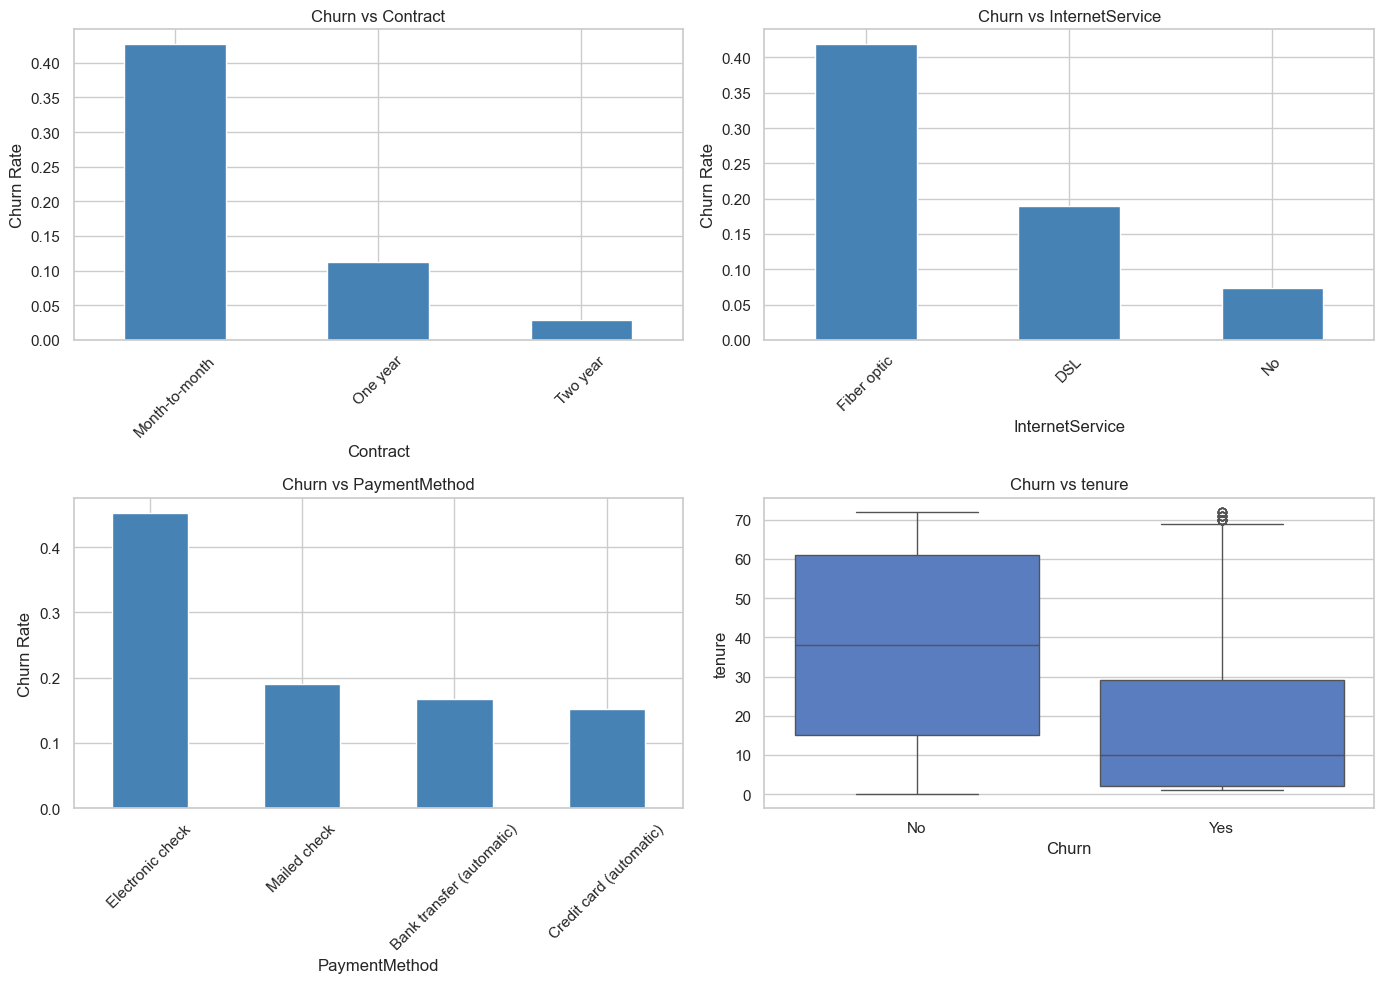

In [32]:
key_features = ['Contract', 'InternetService', 'PaymentMethod', 'tenure']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), key_features):
    if col == 'tenure':
        sns.boxplot(data=df, x='Churn', y=col, ax=ax)
    else:
        churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
        churn_rate.plot(kind='bar', ax=ax, color='steelblue')
        ax.set_ylabel('Churn Rate')
        ax.tick_params(axis='x', rotation=45)
    ax.set_title(f'Churn vs {col}')
plt.tight_layout()
plt.show()

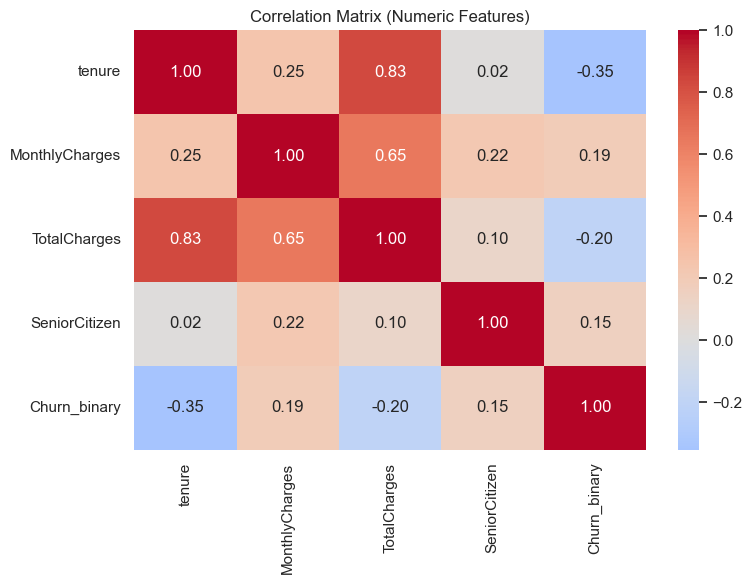

In [33]:
corr_df = df.copy()
corr_df['Churn_binary'] = (corr_df['Churn'] == 'Yes').astype(int)
corr_matrix = corr_df[numeric_cols + ['Churn_binary']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()

### EDA Key Findings
- **Class imbalance:** ~26% churn vs ~74% retained — we use stratified splits and `class_weight='balanced'`.
- **Strong churn signals:** month-to-month contracts, fiber optic internet, electronic check payments, low tenure.
- **Data quality:** 11 rows have missing `TotalCharges` (new customers with tenure=0); impute with median.

## 4. Data Preprocessing

In [34]:
data = df.drop(columns=['customerID']).copy()
data['Churn'] = (data['Churn'] == 'Yes').astype(int)

# Feature engineering
data['avg_monthly_spend'] = data['TotalCharges'] / data['tenure'].replace(0, np.nan)
data['avg_monthly_spend'] = data['avg_monthly_spend'].fillna(data['MonthlyCharges'])
data['has_internet'] = (data['InternetService'] != 'No').astype(int)
data['long_term_contract'] = data['Contract'].isin(['One year', 'Two year']).astype(int)

X = data.drop(columns=['Churn'])
y = data['Churn']

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
                    'avg_monthly_spend', 'has_internet', 'long_term_contract']
categorical_features = [c for c in X.columns if c not in numeric_features]

print(f'Features: {X.shape[1]} total ({len(numeric_features)} numeric, {len(categorical_features)} categorical)')
print(f'Target churn rate: {y.mean():.2%}')

Features: 22 total (7 numeric, 15 categorical)
Target churn rate: 26.54%


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.2%}, Test churn rate: {y_test.mean():.2%}')

Train: (5634, 22), Test: (1409, 22)
Train churn rate: 26.54%, Test churn rate: 26.54%


In [36]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

## 5. Logistic Regression — Training

In [37]:
model = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])

model.fit(X_train, y_train)
print('Logistic Regression trained on training set.')

Logistic Regression trained on training set.


## 6. Model Evaluation

In [38]:
y_proba = model.predict_proba(X_test)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_proba)
test_ap = average_precision_score(y_test, y_proba)

print(f'Test ROC AUC:       {test_roc_auc:.4f}')
print(f'Test Avg Precision:  {test_ap:.4f}')

Test ROC AUC:       0.8414
Test Avg Precision:  0.6319


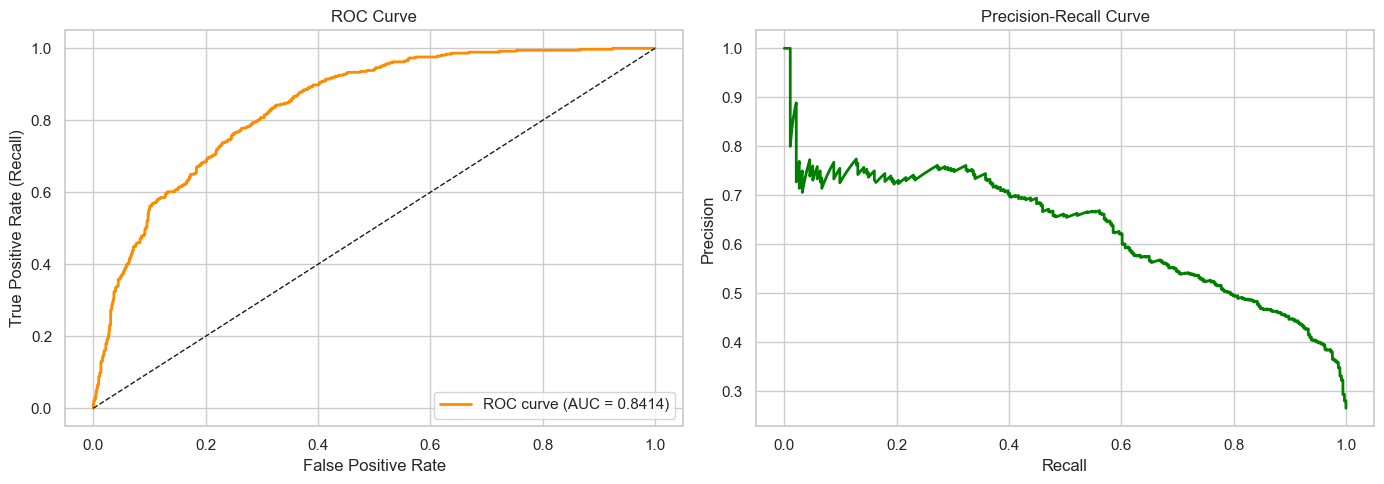

In [39]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

precision, recall, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall, precision, color='green', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
plt.tight_layout()
plt.show()

## 7. Threshold Optimization — Maximize Churn Detection

In [46]:
def metrics_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) else 0
    precision = tp / (tp + fp) if (tp + fp) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    return {'threshold': threshold, 'recall': recall, 'precision': precision, 'f1': f1, 'tp': tp, 'fn': fn}

threshold_grid = np.arange(0.20, 0.71, 0.01)
threshold_metrics = pd.DataFrame([
    metrics_at_threshold(y_test, y_proba, t) for t in threshold_grid
])

high_recall = threshold_metrics[threshold_metrics['recall'] >= 0.85]
if len(high_recall) > 0:
    optimal_row = high_recall.sort_values('f1', ascending=False).iloc[0]
else:
    optimal_row = threshold_metrics.sort_values('f1', ascending=False).iloc[0]

OPTIMAL_THRESHOLD = optimal_row['threshold']
print(f'Optimal classification threshold: {OPTIMAL_THRESHOLD:.2f}')
print(f"  Recall (churn detected): {optimal_row['recall']:.2%}")
print(f"  Precision: {optimal_row['precision']:.2%}")
print(f"  F1 Score: {optimal_row['f1']:.4f}")
print(f"  Churners caught: {int(optimal_row['tp'])} / {int(optimal_row['tp'] + optimal_row['fn'])}")

Optimal classification threshold: 0.40
  Recall (churn detected): 86.63%
  Precision: 46.55%
  F1 Score: 0.6056
  Churners caught: 324 / 374


## 8. Feature Importance

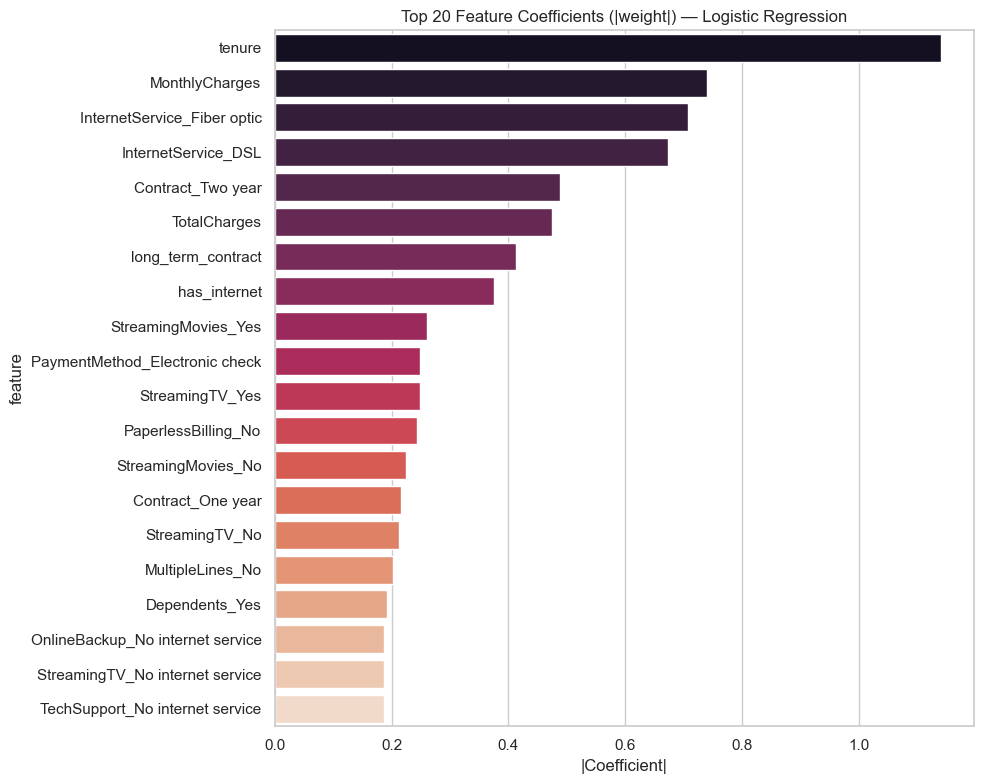

,feature,importance
0,tenure,1.140490
1,MonthlyCharges,0.739472
19,InternetService_Fiber optic,0.708262
18,InternetService_DSL,0.672935
41,Contract_Two year,0.489322
2,TotalCharges,0.475530
6,long_term_contract,0.412751
5,has_internet,0.375581
38,StreamingMovies_Yes,0.260886
46,PaymentMethod_Electronic check,0.249261


In [42]:
feature_names = (
    numeric_features +
    list(model.named_steps['prep'].named_transformers_['cat']
         .named_steps['encoder'].get_feature_names_out(categorical_features))
)

coefficients = np.abs(model.named_steps['clf'].coef_[0])
importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': coefficients})
    .sort_values('importance', ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='importance', y='feature', palette='rocket')
plt.title('Top 20 Feature Coefficients (|weight|) — Logistic Regression')
plt.xlabel('|Coefficient|')
plt.tight_layout()
plt.show()

importance_df

## 9. Save Model & Artifacts

In [43]:
artifacts = {
    'model': model,
    'optimal_threshold': OPTIMAL_THRESHOLD,
    'test_roc_auc': test_roc_auc,
    'feature_names': feature_names,
    'model_type': 'Logistic Regression'
}

joblib.dump(artifacts, 'churn_model_artifacts.joblib')
print('Saved: churn_model_artifacts.joblib')
print('Final model: Logistic Regression')
print(f'Test ROC AUC: {test_roc_auc:.4f}')
print(f'Optimal threshold: {OPTIMAL_THRESHOLD:.2f}')

Saved: churn_model_artifacts.joblib
Final model: Logistic Regression
Test ROC AUC: 0.8414
Optimal threshold: 0.40


## 10. Inference Example

In [44]:
def predict_churn(model, threshold, customer_df):
    proba = model.predict_proba(customer_df)[:, 1]
    return pd.DataFrame({
        'churn_probability': proba,
        'will_churn': (proba >= threshold).astype(int)
    })

sample = X_test.head(5)
predictions = predict_churn(model, OPTIMAL_THRESHOLD, sample)
predictions['actual_churn'] = y_test.loc[sample.index].values
predictions

,churn_probability,will_churn,actual_churn
0,0.116517,0,0
1,0.852432,1,0
2,0.145402,0,0
3,0.661476,1,0
4,0.060788,0,0
